# XGBOOST

Tras evaluar las limitaciones en el rendimiento y la capacidad de generalización del modelo Random Forest previo, se propone la implementación de un algoritmo basado en XGBoost (Extreme Gradient Boosting). El objetivo principal es contrastar ambos enfoques y proveer a la dirección de Gestión del Talento (RRHH) un marco predictivo de mayor precisión operativa, optimizando la toma de decisiones estratégicas ante el riesgo de rotación voluntaria.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from itables import show


## Carga del Dataset

In [3]:
df = pd.read_csv('../data/raw/EmployeeAttrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Vamos a realizar el mismo tratamiento de los datos que con el modelo Random Forest, utilizamos Label Encoding para variables binarias (Si o No), y One-Hot Encoding para el resto de columnas no numéricas.

In [4]:
#Eliminar columnas innecesarias
try:
    cols_to_drop = ['Over18', 'StandardHours', 'EmployeeCount', 'JobLevel', 'StockOptionLevel', 'DailyRate', 'HourlyRate', 'MonthlyRate', 'PercentSalaryHike']
    df = df.drop(columns=cols_to_drop)

except:
    print(df.head())
# Label Encoding para binarias (incluyendo Attrition)
le = LabelEncoder()
binarias = ['Attrition', 'OverTime', 'Gender']
for col in binarias:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding para las demás (Nominales)
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 
                                 'JobRole', 'MaritalStatus'], drop_first=True)

In [5]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

ratio_desbalanceo = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    n_estimators=100,          
    learning_rate=0.3,         
    max_depth=2,
    device='cuda',        # Comentar esta linea para usar la CPU en lugar de la GPU       
    scale_pos_weight=ratio_desbalanceo, 
    eval_metric='logloss',
    random_state=2
)
print("Ratio desbalanceo: ",ratio_desbalanceo)

# Entrenamos el modelo
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred = xgb_model.predict(X_test)

# Evaluamos
print(classification_report(y_test, y_pred))

Ratio desbalanceo:  5.189473684210526
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       247
           1       0.50      0.68      0.58        47

    accuracy                           0.84       294
   macro avg       0.72      0.78      0.74       294
weighted avg       0.87      0.84      0.85       294



d:\Master\TFM\TFMDataScience\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [13:13:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


El conjunto de datos presenta un desbalanceo inherente en la variable objetivo (aproximadamente 1:5.2), lo cual tiende a sesgar el aprendizaje de los clasificadores hacia la clase mayoritaria (permanencia del empleado). Si se emplea la función de pérdida (*Loss Function*) por defecto de XGBoost, los errores de clasificación en ambas clases reciben la misma penalización.

Para mitigar este efecto y priorizar la detección de la fuga de talento, se parametriza el modelo mediante el atributo scale_pos_weight utilizando el ratio de desbalanceo calculado. Matemáticamente, este ajuste pondera de forma asimétrica la función de coste, penalizando con mayor severidad los fallos sobre la clase minoritaria (fuga). Como consecuencia, el algoritmo incrementa de forma controlada su sensibilidad hacia patrones críticos de deserción (tales como sobrecarga laboral, estancamiento salarial o factores sociodemográficos), optimizando el ajuste de los árboles de decisión en los vectores de riesgo.

Nota sobre la optimización analítica: Si el indicador de exhaustividad (Recall) de la clase minoritaria presenta valores moderados en fases iniciales, esto fundamenta la necesidad de aplicar una estrategia de optimización y ajuste fino de hiperparámetros (hiperregularización), o bien una fase posterior de ingeniería de variables (*Feature Engineering*) para extraer combinaciones de atributos con mayor poder discriminante.

## Optimización de Hiperparámetros

Con la finalidad de maximizar el rendimiento predictivo y mitigar los riesgos de sobreajuste (*overfitting*), se procede a realizar un ajuste fino de los hiperparámetros del modelo, reduciendo la tasa de aprendizaje (*Learning Rate*) e incrementando de manera proporcional el volumen de estimadores numéricos (*n_estimators*).

Desde la perspectiva conceptual y de negocio, la estrategia de optimización prioriza el indicador de exhaustividad (*Recall*) sobre la precisión (*Precision*). En el ámbito de la Gestión del Talento, el coste operativo e institucional derivado de un falso positivo (diseñar acciones de retención para un colaborador que no planeaba marcharse) es marginal en comparación con el impacto crítico de un falso negativo (no detectar a tiempo la salida inminente de un activo clave, incurriendo en los elevados costes financieros y de productividad asociados al reclutamiento y la curva de sustitución).

In [6]:
# Vamos a probar a reaujastar el learning_rate, poniendolo mas bajo y aumentando el numero de arboles

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2, stratify=y)

ratio_desbalanceo = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    n_estimators=10000,          
    learning_rate=0.01,         
    max_depth=2,  
    device='cuda',  # Comentar esta linea para usar la CPU en lugar de la GPU            
    scale_pos_weight=ratio_desbalanceo, 
    eval_metric='logloss',
    random_state=2
)
print("Ratio desbalanceo: ",ratio_desbalanceo)

# Entrenamos el modelo
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred = xgb_model.predict(X_test)

# Evaluamos
print(classification_report(y_test, y_pred))

Ratio desbalanceo:  5.198795180722891
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       370
           1       0.51      0.54      0.52        71

    accuracy                           0.84       441
   macro avg       0.71      0.72      0.72       441
weighted avg       0.85      0.84      0.84       441



# MATRIZ DE CONFUSIÓN

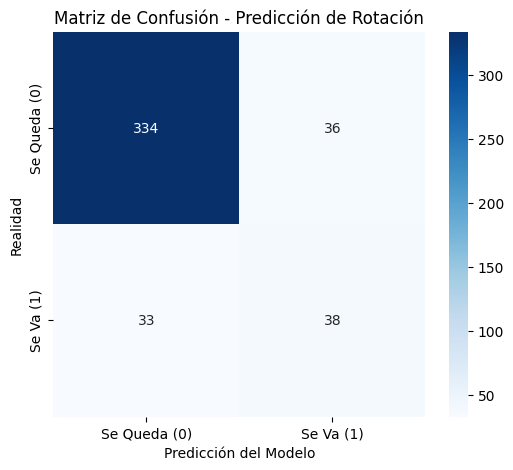

In [7]:
# Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

# Graficar
plt.figure(figsize=(6, 5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Va (1)'], 
            yticklabels=['Se Queda (0)', 'Se Va (1)'])

plt.title('Matriz de Confusión - Predicción de Rotación')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

# Importancia de Variables

C:\Users\lamie\AppData\Local\Temp\ipykernel_14732\4230598373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='magma')


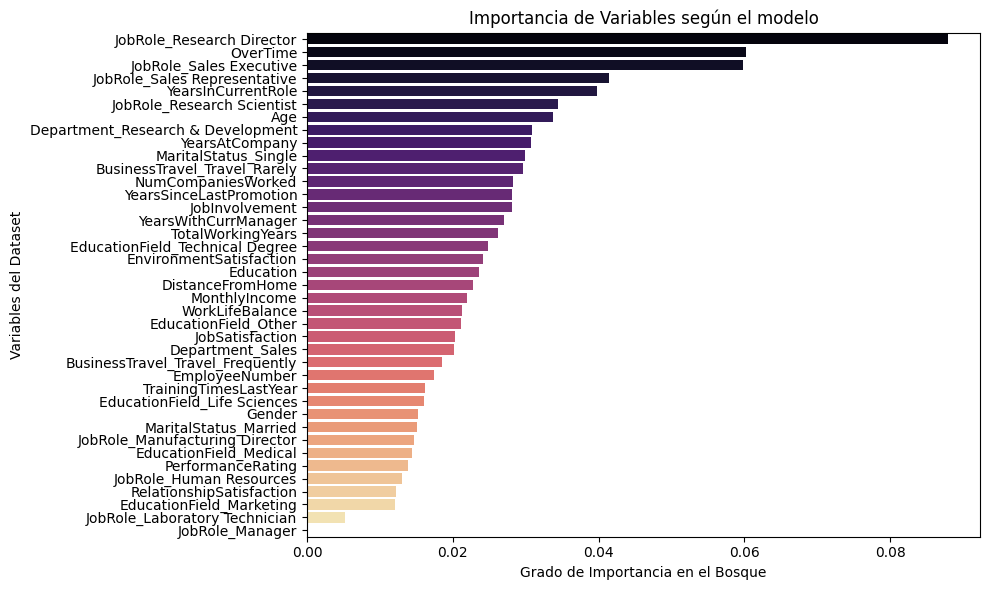

In [8]:
importances = xgb_model.feature_importances_
features = X.columns


df_importances = pd.DataFrame({'Variable': features, 'Importancia': importances})
df_importances = df_importances.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='magma')
plt.title('Importancia de Variables según el modelo')
plt.xlabel('Grado de Importancia en el Bosque')
plt.ylabel('Variables del Dataset')
plt.tight_layout()
plt.show()

In [9]:
# 1. Definimos los cortes de la pirámide basados en las probabilidades
limites = [0, 0.32, 0.70, 1.0]
nombres_niveles = ['3. Base', '2. Cuerpo', '1. Vertice']

probabilidades = xgb_model.predict_proba(X)[:, 1]
df_resultados = pd.DataFrame(index=X.index)

df_resultados['EmployeeNumber'] = df.loc[X.index, 'EmployeeNumber']
df_resultados['Probabilidad_Fuga'] = probabilidades
#df_resultados['Prediccion_Alarma'] = y_pred_personalizado
# 2. Creamos la columna del nivel en nuestro dataframe de resultados
df_resultados['Nivel_Piramide'] = pd.cut(df_resultados['Probabilidad_Fuga'], 
                                         bins=limites, 
                                         labels=nombres_niveles, 
                                         include_lowest=True)

# 3. Unimos los datos originales (características) para poder analizarlos por grupo
df_analisis = df_resultados.join(df[['YearsAtCompany', 'MonthlyIncome', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'OverTime', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single', 'WorkLifeBalance']])

# 4. Contamos cuántos empleados hay en cada escalón de la pirámide
print("--- DISTRIBUCIÓN DE LA PIRÁMIDE ---")
print(df_analisis['Nivel_Piramide'].value_counts().sort_index())
print("\n")

# 5. PERFILADO: Sacamos las características medias de cada grupo
print("--- CARACTERÍSTICAS MEDIAS POR NIVEL ---")
perfil_grupos = df_analisis.groupby('Nivel_Piramide', observed=False)[['Probabilidad_Fuga', 'YearsAtCompany', 'MonthlyIncome', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'OverTime', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single', 'WorkLifeBalance']].mean()
print(perfil_grupos)


--- DISTRIBUCIÓN DE LA PIRÁMIDE ---
Nivel_Piramide
3. Base       1150
2. Cuerpo      104
1. Vertice     216
Name: count, dtype: int64


--- CARACTERÍSTICAS MEDIAS POR NIVEL ---
                Probabilidad_Fuga  YearsAtCompany  MonthlyIncome  \
Nivel_Piramide                                                     
3. Base                  0.059590        7.667826    7044.625217   
2. Cuerpo                0.462082        4.875000    4811.663462   
1. Vertice               0.911172        4.523148    4433.226852   

                DistanceFromHome  Education  EnvironmentSatisfaction  \
Nivel_Piramide                                                         
3. Base                 8.833043   2.934783                 2.786087   
2. Cuerpo               9.980769   2.855769                 2.644231   
1. Vertice             10.726852   2.824074                 2.416667   

                JobInvolvement  JobSatisfaction  OverTime  \
Nivel_Piramide                                              

Para crear una tabla en la que se pueda interactuar, vamos a deshacer las variables dummy para que sea más fácil hacer un análisis

In [10]:
# Creamos una columna JobRole para definir el puesto de trabajo en el que está el empleado
columnas_jobrole = [col for col in df_analisis.columns if col.startswith('JobRole_')]

df_analisis['JobRole'] = df_analisis[columnas_jobrole].idxmax(axis=1)

df_analisis['JobRole'] = df_analisis['JobRole'].str.replace('JobRole_', '', regex=False)

# Realizamos la misma operación para el estado civil
columnas_maritalstatus = [col for col in df_analisis.columns if col.startswith('MaritalStatus_')]

df_analisis['MaritalStatus'] = df_analisis[columnas_maritalstatus].idxmax(axis=1)

df_analisis['MaritalStatus'] = df_analisis['MaritalStatus'].str.replace('MaritalStatus_', '', regex=False)

En comparación a Random Forest, se puede apreciar que con XGBoost ha podido ver el patrón también del departamento, ya que la mayoría de los empleados que se van son del departamento de ventas

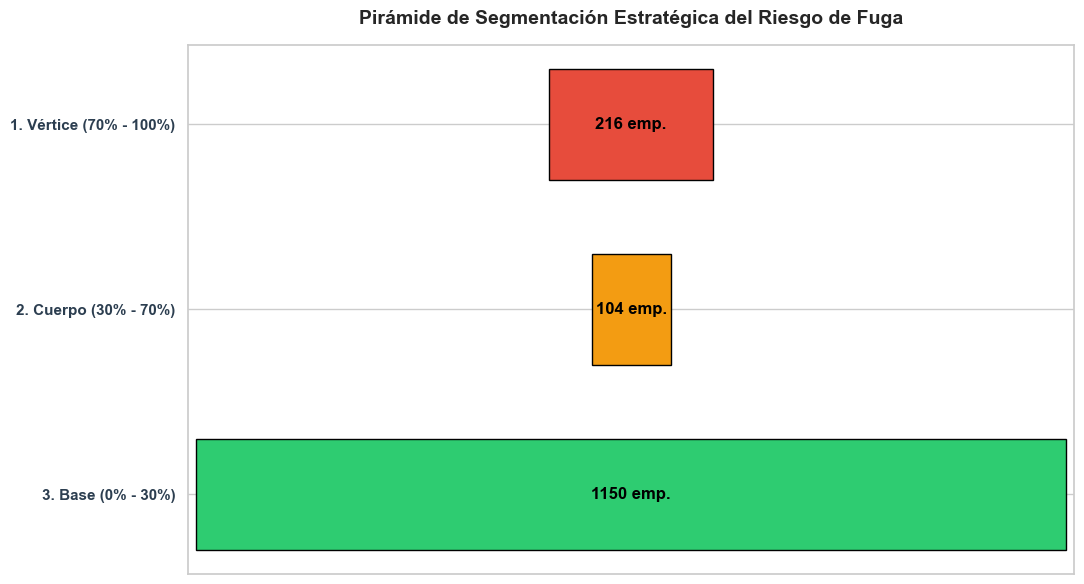

In [11]:
conteos = df_analisis['Nivel_Piramide'].value_counts().sort_index(ascending=True)

niveles = conteos.index
valores = conteos.values
max_val = max(valores)

etiquetas = []
for nivel in niveles:
    nivel_str = str(nivel).lower()
    if 'base' in nivel_str:
        etiquetas.append('3. Base (0% - 30%)')
    elif 'cuerpo' in nivel_str:
        etiquetas.append('2. Cuerpo (30% - 70%)')
    elif 'v' in nivel_str:  # Captura 'Vértice' o 'Vertice'
        etiquetas.append('1. Vértice (70% - 100%)')
    else:
        etiquetas.append(str(nivel)) 
# ---------------------------------------------------------------------------

# Configuración del gráfico
plt.figure(figsize=(11, 6)) 
sb.set_theme(style="whitegrid")

left_coords = (max_val - valores) / 2
colores = ['#2ecc71', '#f39c12', '#e74c3c'] 

bars = plt.barh(niveles, valores, left=left_coords, color=colores, edgecolor='black', height=0.6)


plt.yticks(range(len(niveles)), etiquetas, fontsize=11, fontweight='bold', color='#2c3e50')

# Añadir las etiquetas con el número exacto de empleados dentro de las barras
for bar, val in zip(bars, valores):
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_y() + bar.get_height() / 2
    plt.text(x_pos, y_pos, f'{val} emp.', 
             va='center', ha='center', color='black', fontweight='bold', fontsize=12)

plt.title('Pirámide de Segmentación Estratégica del Riesgo de Fuga', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Volumen de Empleados (Centrado)', fontsize=11)
plt.xlim(-10, max_val + 10) # Margen dinámico
plt.gca().axes.get_xaxis().set_visible(False) # Ocultamos el eje X numérico ya que está descentrado

plt.tight_layout()
plt.show()

# CUADRANTE COMPARATIVO DE RIESGO DE FUGA VS. DISTANCIA DE CASA

C:\Users\lamie\AppData\Local\Temp\ipykernel_14732\1804433426.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.scatterplot(


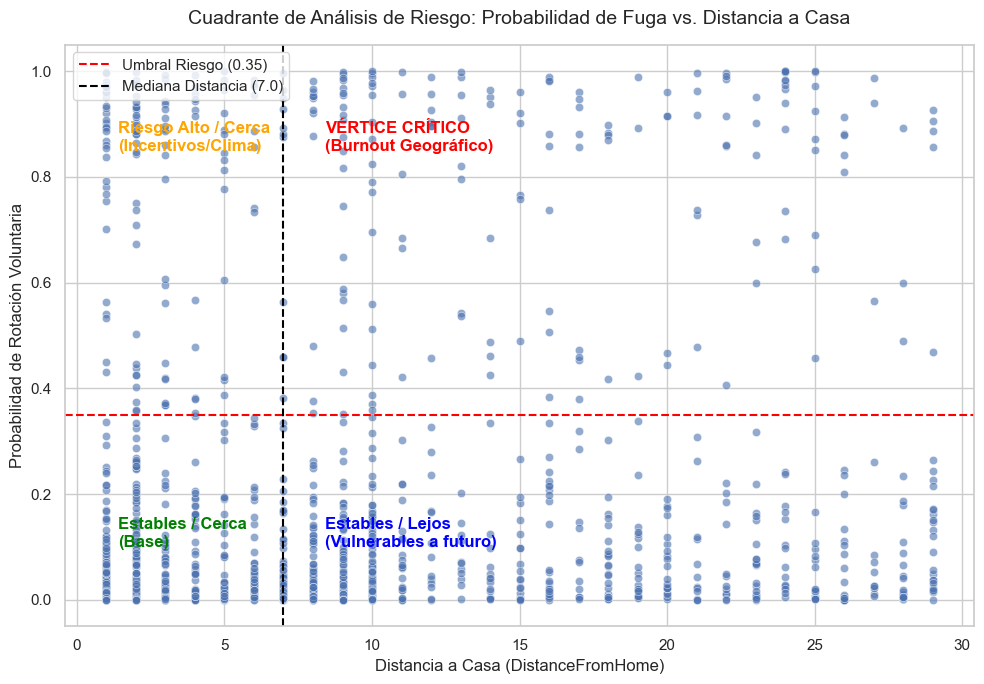

In [12]:
# Configuración de estilo
sb.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# Definición de umbrales para los cuadrantes
umbral_prob = 0.35  # Basado en la calibración de costes (0.32 - 0.40)
umbral_dist = df['DistanceFromHome'].median()  # O un valor fijo de negocio

# Gráfico de dispersión
sb.scatterplot(
    data=df_analisis, 
    x='DistanceFromHome', 
    y='Probabilidad_Fuga', 
    alpha=0.6, 
    # hue='Probabilidad_Fuga', # Para ver visualmente quiénes se fueron realmente
    palette={1: '#d9534f', 0: '#5cb85c'}
)

# Líneas divisorias de cuadrantes
plt.axhline(y=umbral_prob, color='red', linestyle='--', linewidth=1.5, label=f'Umbral Riesgo ({umbral_prob})')
plt.axvline(x=umbral_dist, color='black', linestyle='--', linewidth=1.5, label=f'Mediana Distancia ({umbral_dist:.1f})')

# Textos para identificar los cuadrantes
plt.text(umbral_dist * 0.2, 0.85, "Riesgo Alto / Cerca\n(Incentivos/Clima)", color='orange', weight='bold')
plt.text(umbral_dist * 1.2, 0.85, "VÉRTICE CRÍTICO\n(Burnout Geográfico)", color='red', weight='bold')
plt.text(umbral_dist * 0.2, 0.10, "Estables / Cerca\n(Base)", color='green', weight='bold')
plt.text(umbral_dist * 1.2, 0.10, "Estables / Lejos\n(Vulnerables a futuro)", color='blue', weight='bold')

plt.title('Cuadrante de Análisis de Riesgo: Probabilidad de Fuga vs. Distancia a Casa', fontsize=14, pad=15)
plt.xlabel('Distancia a Casa (DistanceFromHome)', fontsize=12)
plt.ylabel('Probabilidad de Rotación Voluntaria', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# CUADRANTE COMPARATIVO DE RIESGO DE FUGA VS. ESTADO CIVIL

C:\Users\lamie\AppData\Local\Temp\ipykernel_14732\2270391759.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
C:\Users\lamie\AppData\Local\Temp\ipykernel_14732\2270391759.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.stripplot(


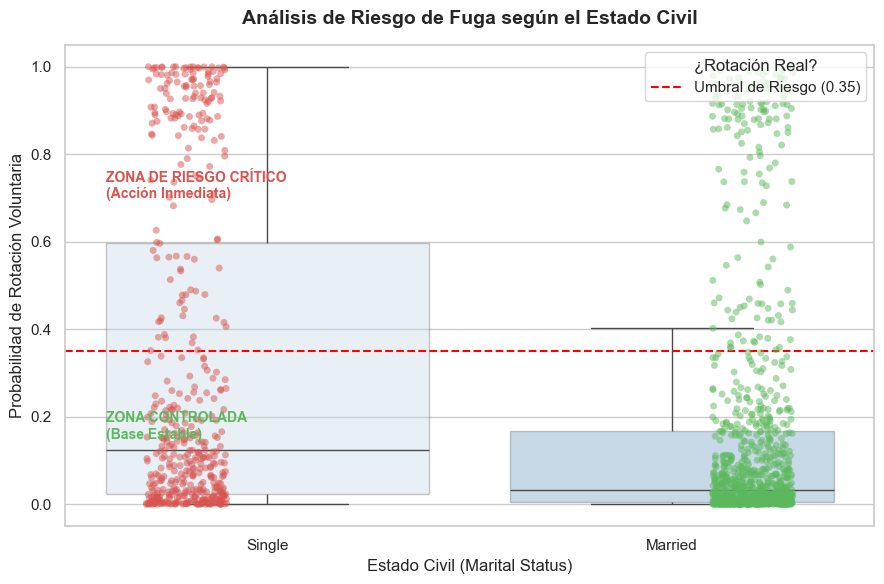

In [20]:
# Configuración de estilo premium
sb.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# El único umbral necesario es el de probabilidad (Y)
umbral_prob = 0.35  

# 1. Dibujamos diagramas de caja (Boxplots) transparentes para ver la distribución y la mediana
sb.boxplot(
    data=df_analisis, 
    x='MaritalStatus', 
    y='Probabilidad_Fuga', 
    palette="Blues", 
    fliersize=0,  # Ocultamos los outliers del boxplot para no duplicarlos con los puntos
    boxprops=dict(alpha=0.3)
)

# 2. Añadimos los puntos reales con "jitter" (dispersión horizontal) para ver la densidad de empleados
# Usamos 'Attrition' (o la variable real de si se fueron) para pintar el color
sb.stripplot(
    data=df_analisis, 
    x='MaritalStatus', 
    y='Probabilidad_Fuga', 
    #hue='Attrition',  # Cambia por la variable real de tu dataset (ej: 'Attrition' o 'Fuga')
    palette={'Single': '#d9534f', 'Married': '#5cb85c'}, # Rojo para los que se fueron, verde para los que no
    alpha=0.5, 
    jitter=0.2,
    dodge=True
)

# Línea divisoria horizontal de riesgo (calibrada por negocio)
plt.axhline(y=umbral_prob, color='red', linestyle='--', linewidth=1.5, label=f'Umbral de Riesgo ({umbral_prob})')

# Textos de análisis estratégico
plt.text(-0.4, 0.70, "ZONA DE RIESGO CRÍTICO\n(Acción Inmediata)", color='#d9534f', weight='bold', fontsize=10)
plt.text(-0.4, 0.15, "ZONA CONTROLADA\n(Base Estable)", color='#5cb85c', weight='bold', fontsize=10)

# Detalles finales
plt.title('Análisis de Riesgo de Fuga según el Estado Civil', fontsize=14, pad=15, weight='bold')
plt.xlabel('Estado Civil (Marital Status)', fontsize=12)
plt.ylabel('Probabilidad de Rotación Voluntaria', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(title="¿Rotación Real?", loc='upper right')
plt.tight_layout()
plt.show()

# CUADRANTE COMPARATIVO DE RIESGO DE FUGA VS. AÑOS EN LA COMPAÑÍA

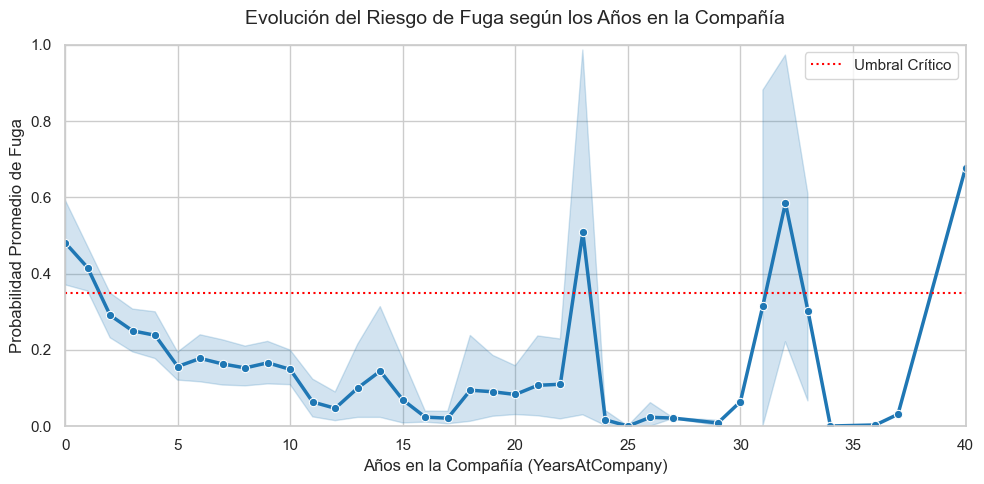

In [14]:
plt.figure(figsize=(10, 5))

# Gráfico de línea suavizado para ver la tendencia por años en la empresa
sb.lineplot(
    data=df_analisis, 
    x='YearsAtCompany', 
    y='Probabilidad_Fuga', 
    color='#1f77b4', 
    linewidth=2.5,
    marker='o'
)

# Línea del umbral de riesgo corporativo para referencia
plt.axhline(y=umbral_prob, color='red', linestyle=':', label='Umbral Crítico')

plt.title('Evolución del Riesgo de Fuga según los Años en la Compañía', fontsize=14, pad=15)
plt.xlabel('Años en la Compañía (YearsAtCompany)', fontsize=12)
plt.ylabel('Probabilidad Promedio de Fuga', fontsize=12)
plt.xlim(0, df['YearsAtCompany'].max())
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# BOXPLOT DE PROBABILIDAD DE FUGA POR ROL

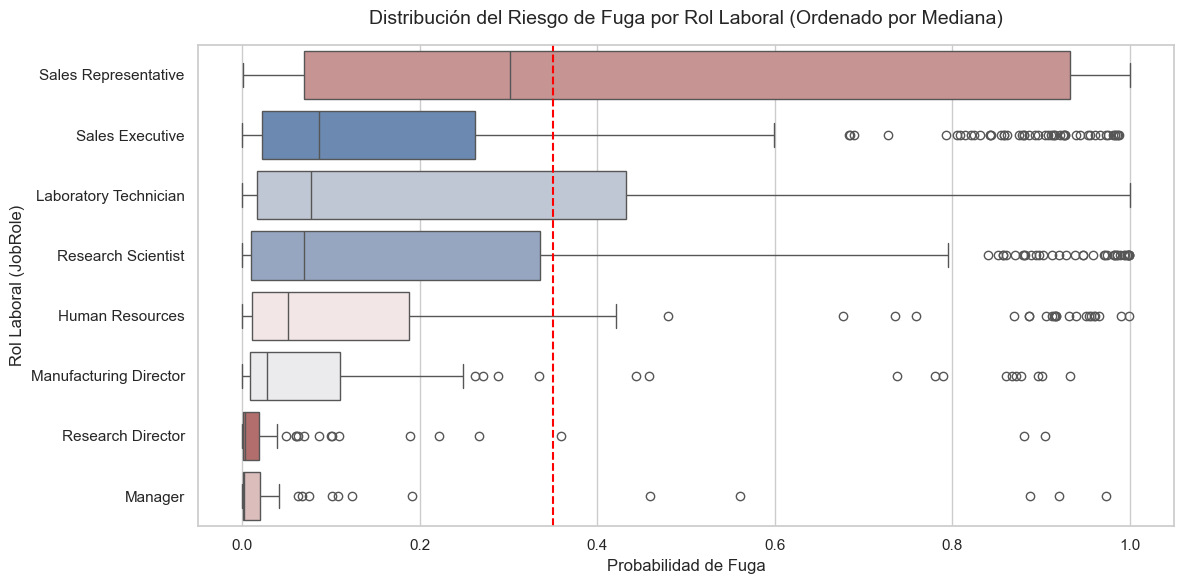

In [15]:
plt.figure(figsize=(12, 6))

# Ordenar los roles por la mediana de la probabilidad de fuga de forma descendente
order = df_analisis.groupby('JobRole')['Probabilidad_Fuga'].median().sort_values(ascending=False).index

sb.boxplot(
    data=df_analisis, 
    x='Probabilidad_Fuga', 
    y='JobRole', 
    order=order, 
    palette='vlag',
    hue='JobRole',
    legend=False
)

plt.axvline(x=umbral_prob, color='red', linestyle='--')
plt.title('Distribución del Riesgo de Fuga por Rol Laboral (Ordenado por Mediana)', fontsize=14, pad=15)
plt.xlabel('Probabilidad de Fuga', fontsize=12)
plt.ylabel('Rol Laboral (JobRole)', fontsize=12)
plt.tight_layout()
plt.show()

# GRÁFICO DE DISPERSIÓN DE INGRESO MENSUAL VS. PROBABILIDAD, SEGMENTADO POR HORAS EXTRAS

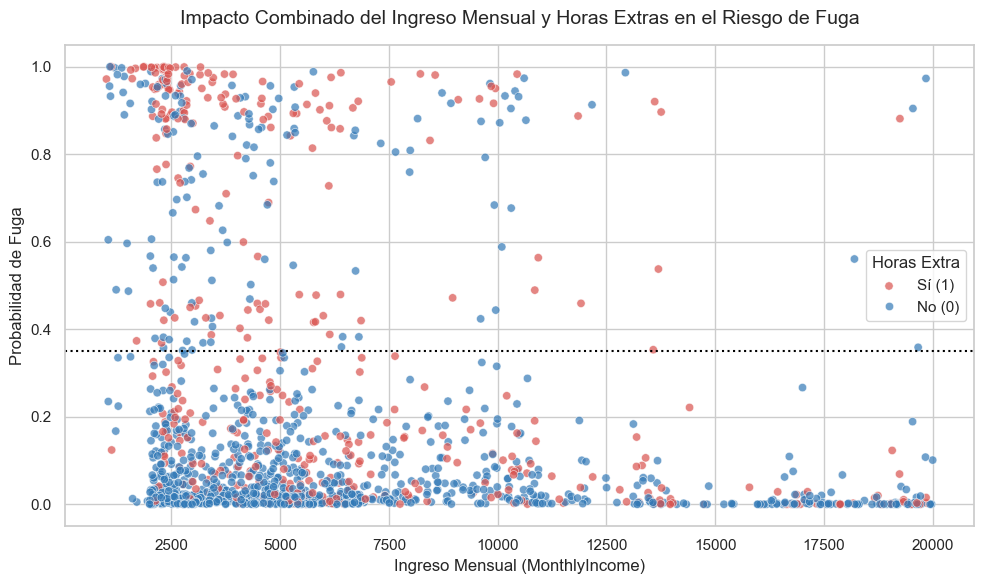

In [16]:
plt.figure(figsize=(10, 6))

sb.scatterplot(
    data=df_analisis, 
    x='MonthlyIncome', 
    y='Probabilidad_Fuga', 
    hue='OverTime', 
    palette={1: '#d9534f', 0: '#337ab7'}, 
    alpha=0.7
)

plt.axhline(y=umbral_prob, color='black', linestyle=':')
plt.legend(title='Horas Extra', labels=['Sí (1)', 'No (0)'])
plt.title('Impacto Combinado del Ingreso Mensual y Horas Extras en el Riesgo de Fuga', fontsize=14, pad=15)
plt.xlabel('Ingreso Mensual (MonthlyIncome)', fontsize=12)
plt.ylabel('Probabilidad de Fuga', fontsize=12)
plt.tight_layout()
plt.show()

Vamos a crear un selector para poder sacar un listado de los id de los empleados y la probabilidad de que se vayan dependiendo del nivel de la pirámide que queramos explorar, modificando la variable opcion, podemos consultar el listado de los empleados que están en cada uno de los niveles de la pirámide

In [17]:
# # Seleccionamos que nivel de la piramide que deseamos consultar el listado de los empleados que hay.
# # 1 = Nivel critico (Vertice)
# # 2 = Nivel medio
# # 3 = Nivel bajo (Base)

opcion = 1

match opcion:
   case 1: 
      filtro_df = df_analisis[df_analisis['Nivel_Piramide'] == '1. Vertice']

   case 2:
      filtro_df = df_analisis[df_analisis['Nivel_Piramide'] == '2. Cuerpo']

   case 3:
      filtro_df = df_analisis[df_analisis['Nivel_Piramide'] == '3. Base']


filtro_df = filtro_df.sort_values(by='Probabilidad_Fuga', ascending=False)

# Vamos a borrar las columnas dummies para limipiar el dataframe y que sea más fácil filtrar la itable y quitar ruido
filtro_df = filtro_df.drop(columns = ['JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single'] )

show(filtro_df, column_filters='header', showIndex=False)

Loading ITables v2.8.0 from the internet... (need help?)


# Índices

<details>
<summary>Education</summary>
1 'Below College'
2 'College'
3 'Bachelor'
4 'Master'
5 'Doctor'
</details>

<details>
<summary> EnvironmentSatisfaction </summary>
1 'Low'
2 'Medium'
3 'High'
4 'Very High'
</details>

<details>
<summary> JobInvolvement </summary>
1 'Low'
2 'Medium'
3 'High'
4 'Very High'
</details>

<details>
<summary> JobSatisfaction </summary>
1 'Low'
2 'Medium'
3 'High'
4 'Very High'
</details>

<details>
<summary> WorkLifeBalance </summary>
1 'Bad'
2 'Good'
3 'Better'
4 'Best'
</details>


La integración de los resultados predictivos con las dimensiones sociodemográficas e históricas permite realizar un perfilado multidimensional de la estructura organizativa. A través de este análisis, se identifican con claridad los vectores y atributos con mayor ponderación en el fenómeno de la baja voluntaria (departamentos críticos, niveles de satisfacción interna o distancia al núcleo de trabajo).

El desglose analítico de los segmentos de alta vulnerabilidad (estrato del Vértice) muestra una concentración predecible en perfiles específicos: colaboradores con estado civil soltero, desplazamientos prolongados hacia el centro de trabajo y funciones ligadas al área técnica (p. ej., Técnicos de Laboratorio).

Con el propósito de trasladar este modelo matemático a una herramienta de software accionable para los tomadores de decisiones de la organización, se integra la librería interactiva itables. Esto dota al entorno de capacidades dinámicas de consulta y auditoría individual de registros, facilitando a Gestión del Talento el diseño ágil y personalizado de políticas de retención efectivas.